# Regression Pipeline - Automatisk val av bästa modell

**Syfte:** Besvara frågorna från regression_example och demonstrera en komplett regression pipeline med automatisk val av bästa modell

## Svar på frågorna

### Fråga 1: Förklara vad koden gör. Vilka är huvudstegen?

**Svar:**

Koden demonstrerar en komplett **regression pipeline** med följande huvudsteg:

**1. Data Preparation:**
- Skapar syntetisk regressionsdata med 1000 samples och 5 features
- Konverterar till DataFrame för enkel hantering

**2. Data Splitting:**
- Delar data i **train/validation/test** (60%/20%/20%)
- Använder tvåstegs-split för att få rätt proportioner

**3. EDA (Exploratory Data Analysis):**
- Visualiserar target-variabelns fördelning
- Beräknar korrelationer mellan features och target

**4. Model Training:**
- **Linear Regression**: Enkel modell utan hyperparameter-tuning
- **Decision Tree**: Med GridSearchCV för hyperparameter-optimering

**5. Model Evaluation:**
- Jämför modeller med RMSE på validation data
- Linear Regression presterar bättre (RMSE: 20.7 vs 41.2)

**6. Final Testing:**
- Tränar bästa modell på hela train+validation data
- Testar på held-out test data (RMSE: 20.5)

**7. Model Persistence:**
- Sparar tränad modell med joblib
- Demonstrerar hur man laddar och använder sparad modell

### Fråga 2: Vad gör denna kod?

```python
print(tree_reg_gs.best_params_)
pd.DataFrame(tree_reg_gs.cv_results_)
```

**Svar:**

**`tree_reg_gs.best_params_`** - Visar de **bästa hyperparametrarna** som GridSearchCV hittade för Decision Tree-modellen. Detta är resultatet av att testa alla kombinationer av:
- `max_depth`: [3, 5, 7, None]
- `min_samples_split`: [2, 5, 10] 
- `min_samples_leaf`: [1, 2, 4]

**`pd.DataFrame(tree_reg_gs.cv_results_)`** - Skapar en DataFrame med **alla resultat** från GridSearchCV, inklusive:
- Prestanda för varje hyperparameter-kombination
- Cross-validation scores
- Standardavvikelser
- Rankning av alla kombinationer

Detta ger fullständig insikt i hur olika hyperparametrar påverkar modellprestanda.

### Fråga 3: Lägg till en tredje modell (Random Forest)

**Svar:** Vi lägger till Random Forest-modellen i implementationen nedan tillsammans med automatisk val av bästa modell.

## Implementation

### 1. Importera bibliotek

In [1]:
# Grundläggande bibliotek
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn för machine learning
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
import joblib

# Sätt stil för plots
plt.style.use('default')
sns.set_palette('husl')

print('Alla bibliotek importerade!')


Alla bibliotek importerade!


### 2. Skapa och förbereda data

In [2]:
# Skapa syntetisk regressionsdata
# 1000 samples, 5 features, noise=20 för realism
X, y = make_regression(n_samples=1000, n_features=5, noise=20, random_state=42)

# Konvertera till DataFrame för enkel hantering
df = pd.DataFrame(X, columns=[f'Feature_{i}' for i in range(5)])
df['Target'] = y

# Separera features och target
X = df.drop('Target', axis=1)
y = df['Target']

print(f'Data shape: {df.shape}')
print(f'Features: {list(X.columns)}')
print(f'Target range: {y.min():.2f} to {y.max():.2f}')


Data shape: (1000, 6)
Features: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
Target range: -234.30 to 197.38


### 3. Dela data i train/validation/test

In [3]:
# Första split: 80% train+val, 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Andra split: 75% train, 25% validation (av de 80%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42
)

print(f'Train: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')


Train: 600 samples (60.0%)
Validation: 200 samples (20.0%)
Test: 200 samples (20.0%)


### 4. Träna modeller

In [4]:
# 1. Linear Regression (enkel modell)
print('Tränar Linear Regression...')
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_val)
lr_rmse = root_mean_squared_error(lr_pred, y_val)

# 2. Decision Tree med GridSearchCV
print('Tränar Decision Tree med GridSearchCV...')
dt = DecisionTreeRegressor(random_state=42)
# Hyperparametrar att testa
dt_params = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
dt_gs = GridSearchCV(dt, dt_params, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
dt_gs.fit(X_train, y_train)
dt_pred = dt_gs.predict(X_val)
dt_rmse = root_mean_squared_error(dt_pred, y_val)

# 3. Random Forest med GridSearchCV
print('Tränar Random Forest med GridSearchCV...')
rf = RandomForestRegressor(random_state=42)
# Hyperparametrar att testa
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10]
}
rf_gs = GridSearchCV(rf, rf_params, scoring='neg_mean_squared_error', cv=5, n_jobs=-1)
rf_gs.fit(X_train, y_train)
rf_pred = rf_gs.predict(X_val)
rf_rmse = root_mean_squared_error(rf_pred, y_val)

print('\nModellprestanda (Validation RMSE):')
print(f'Linear Regression: {lr_rmse:.2f}')
print(f'Decision Tree: {dt_rmse:.2f}')
print(f'Random Forest: {rf_rmse:.2f}')


Tränar Linear Regression...
Tränar Decision Tree med GridSearchCV...
Tränar Random Forest med GridSearchCV...

Modellprestanda (Validation RMSE):
Linear Regression: 21.86
Decision Tree: 43.26
Random Forest: 32.24


### 5. Analysera GridSearchCV-resultat

In [5]:
# Visa bästa parametrar för Decision Tree
print('Decision Tree - Bästa parametrar:')
print(dt_gs.best_params_)
print(f'Bästa score: {dt_gs.best_score_:.2f}')

# Visa bästa parametrar för Random Forest
print('\nRandom Forest - Bästa parametrar:')
print(rf_gs.best_params_)
print(f'Bästa score: {rf_gs.best_score_:.2f}')

# Visa top 3 kombinationer för Decision Tree
dt_results = pd.DataFrame(dt_gs.cv_results_)
dt_top3 = dt_results.nlargest(3, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print('\nDecision Tree - Top 3 kombinationer:')
print(dt_top3)


Decision Tree - Bästa parametrar:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
Bästa score: -1499.98

Random Forest - Bästa parametrar:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Bästa score: -795.81

Decision Tree - Top 3 kombinationer:
                                               params  mean_test_score  \
33  {'max_depth': None, 'min_samples_leaf': 4, 'mi...     -1499.977533   
34  {'max_depth': None, 'min_samples_leaf': 4, 'mi...     -1499.977533   
35  {'max_depth': None, 'min_samples_leaf': 4, 'mi...     -1519.682439   

    std_test_score  
33      106.258930  
34      106.258930  
35       88.356998  


### 6. Feature Importance Analysis

In [6]:
# Beräkna feature importance för alla modeller
def get_feature_importance(model, model_name, X_train, y_train):
    """Beräkna feature importance för en modell"""
    if model_name == 'Linear Regression':
        # För Linear Regression: använd absoluta värden av koefficienter
        # Standardisera först för rättvis jämförelse
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        model.fit(X_train_scaled, y_train)
        importance = np.abs(model.coef_)
    else:
        # För tree-based models: använd feature_importances_
        importance = model.feature_importances_
    
    return importance

# Hämta importance för alla modeller
lr_importance = get_feature_importance(lr, 'Linear Regression', X_train, y_train)
dt_importance = get_feature_importance(dt_gs.best_estimator_, 'Decision Tree', X_train, y_train)
rf_importance = get_feature_importance(rf_gs.best_estimator_, 'Random Forest', X_train, y_train)

# Skapa DataFrame för jämförelse
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Linear_Regression': lr_importance,
    'Decision_Tree': dt_importance,
    'Random_Forest': rf_importance
})

# Normalisera till 0-1 skala för rättvis jämförelse
for col in ['Linear_Regression', 'Decision_Tree', 'Random_Forest']:
    importance_df[f'{col}_norm'] = importance_df[col] / importance_df[col].max()

print('Feature Importance (normaliserad 0-1):')
print(importance_df[['Feature', 'Linear_Regression_norm', 'Decision_Tree_norm', 'Random_Forest_norm']].round(3))


Feature Importance (normaliserad 0-1):
     Feature  Linear_Regression_norm  Decision_Tree_norm  Random_Forest_norm
0  Feature_0                   0.574               0.339               0.327
1  Feature_1                   1.000               1.000               1.000
2  Feature_2                   0.362               0.137               0.119
3  Feature_3                   0.531               0.233               0.264
4  Feature_4                   0.444               0.143               0.160


### 7. Visualisera Feature Importance

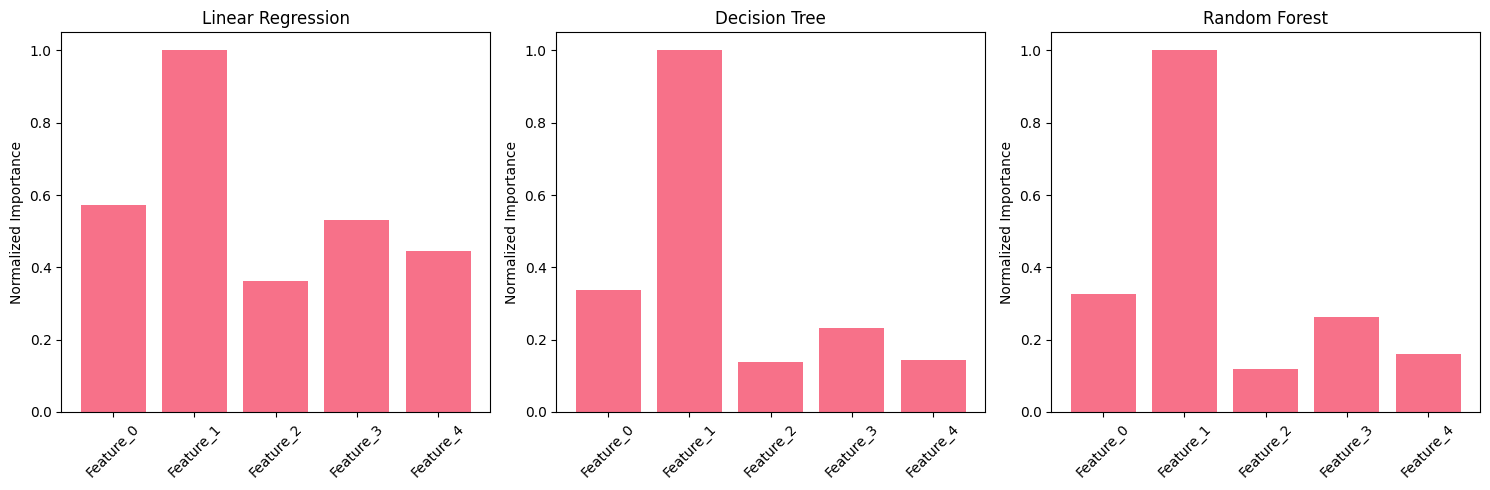

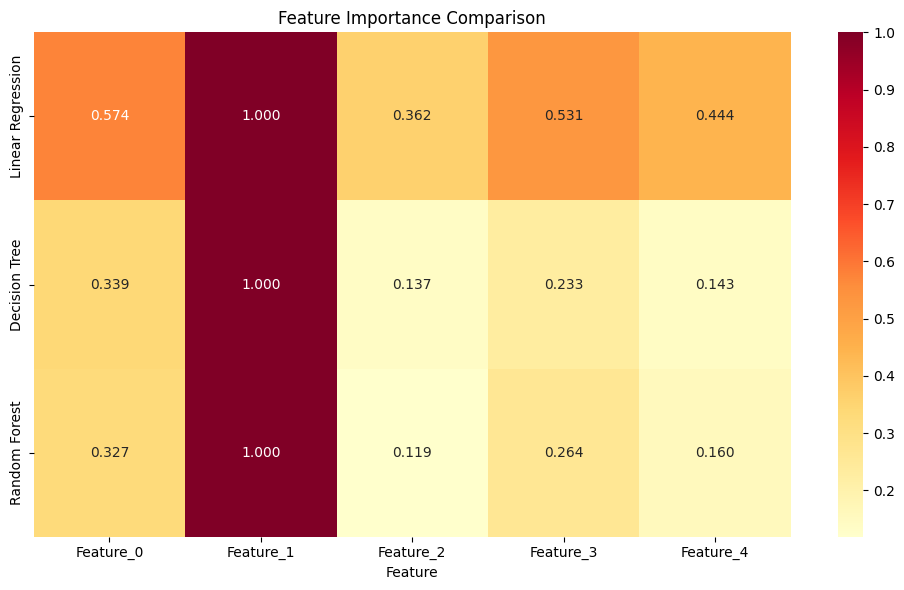

In [7]:
# Skapa subplots för alla modeller
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = ['Linear_Regression_norm', 'Decision_Tree_norm', 'Random_Forest_norm']
titles = ['Linear Regression', 'Decision Tree', 'Random Forest']

for i, (model, title) in enumerate(zip(models, titles)):
    axes[i].bar(importance_df['Feature'], importance_df[model])
    axes[i].set_title(title)
    axes[i].set_ylabel('Normalized Importance')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Heatmap för översiktlig jämförelse
plt.figure(figsize=(10, 6))
heatmap_data = importance_df[['Linear_Regression_norm', 'Decision_Tree_norm', 'Random_Forest_norm']].T
heatmap_data.columns = importance_df['Feature']
heatmap_data.index = ['Linear Regression', 'Decision Tree', 'Random Forest']

sns.heatmap(heatmap_data, annot=True, cmap='YlOrRd', fmt='.3f')
plt.title('Feature Importance Comparison')
plt.tight_layout()
plt.show()


### 8. Välj bästa features och testa

In [8]:
# Välj top 3 features baserat på genomsnittlig importance
importance_df['Average_Importance'] = (
    importance_df['Linear_Regression_norm'] + 
    importance_df['Decision_Tree_norm'] + 
    importance_df['Random_Forest_norm']
) / 3

# Sortera efter genomsnittlig importance
importance_df = importance_df.sort_values('Average_Importance', ascending=False)
selected_features = importance_df.head(3)['Feature'].tolist()

print(f'Valda features: {selected_features}')
print('\nFeature ranking:')
print(importance_df[['Feature', 'Average_Importance']].round(3))

# Skapa nya datasets med valda features
X_train_selected = X_train[selected_features]
X_val_selected = X_val[selected_features]
X_test_selected = X_test[selected_features]


Valda features: ['Feature_1', 'Feature_0', 'Feature_3']

Feature ranking:
     Feature  Average_Importance
1  Feature_1               1.000
0  Feature_0               0.413
3  Feature_3               0.342
4  Feature_4               0.249
2  Feature_2               0.206


### 9. Träna modeller med valda features

In [9]:
# Träna alla modeller med valda features
def train_model_with_features(model, model_name, X_train, y_train, X_val, y_val):
    """Träna modell med valda features och returnera RMSE"""
    if model_name == 'Linear Regression':
        # Standardisera för Linear Regression
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_val_scaled)
    else:
        # Tree-based models behöver ingen standardisering
        model.fit(X_train, y_train)
        pred = model.predict(X_val)
    
    return root_mean_squared_error(pred, y_val)

# Träna med valda features
lr_rmse_selected = train_model_with_features(lr, 'Linear Regression', X_train_selected, y_train, X_val_selected, y_val)
dt_rmse_selected = train_model_with_features(dt_gs.best_estimator_, 'Decision Tree', X_train_selected, y_train, X_val_selected, y_val)
rf_rmse_selected = train_model_with_features(rf_gs.best_estimator_, 'Random Forest', X_train_selected, y_train, X_val_selected, y_val)

print('Modellprestanda med valda features:')
print(f'Linear Regression: {lr_rmse_selected:.2f}')
print(f'Decision Tree: {dt_rmse_selected:.2f}')
print(f'Random Forest: {rf_rmse_selected:.2f}')


Modellprestanda med valda features:
Linear Regression: 35.37
Decision Tree: 43.84
Random Forest: 40.53


### 10. Jämför prestanda

Prestandajämförelse:
               Model  All_Features  Selected_Features  Improvement
0  Linear Regression         21.86              35.37       -61.85
1      Decision Tree         43.26              43.84        -1.34
2      Random Forest         32.24              40.53       -25.72


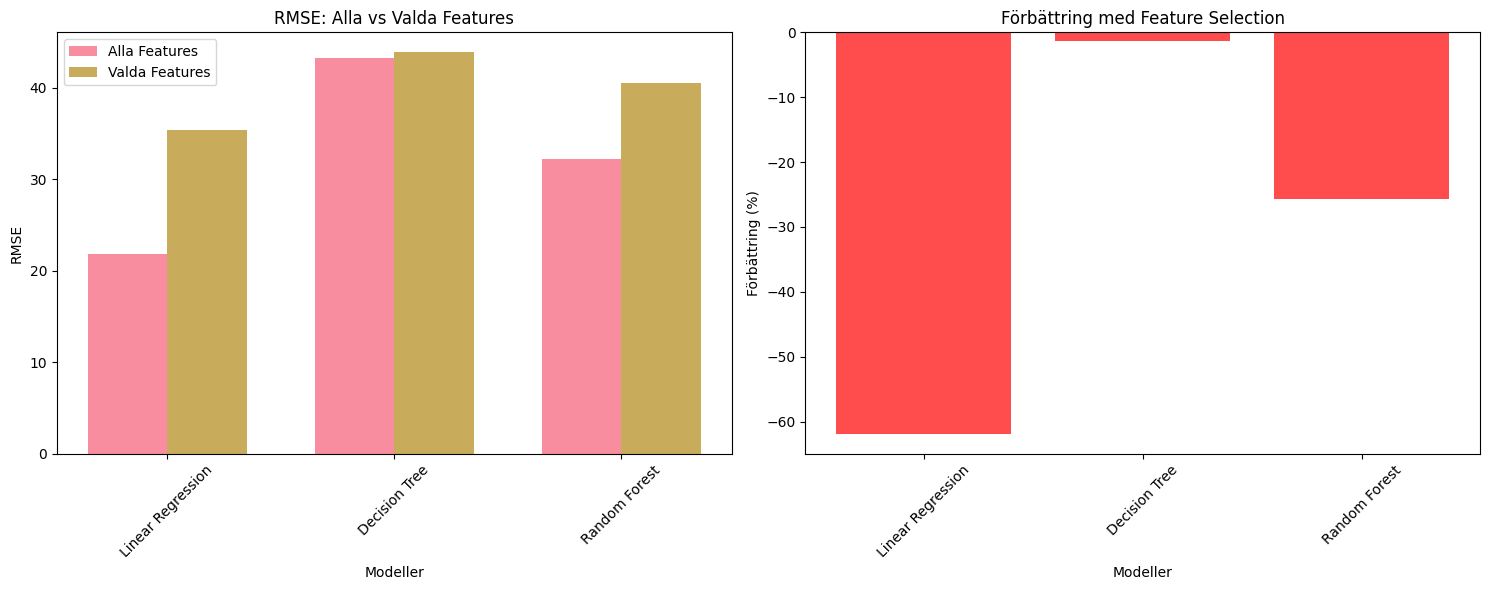

In [10]:
# Skapa jämförelse
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'All_Features': [lr_rmse, dt_rmse, rf_rmse],
    'Selected_Features': [lr_rmse_selected, dt_rmse_selected, rf_rmse_selected]
})

# Beräkna förbättring i procent
comparison['Improvement'] = ((comparison['All_Features'] - comparison['Selected_Features']) / 
                           comparison['All_Features'] * 100)

print('Prestandajämförelse:')
print(comparison.round(2))

# Visualisera jämförelse
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# RMSE jämförelse
x = np.arange(len(comparison))
width = 0.35

ax1.bar(x - width/2, comparison['All_Features'], width, label='Alla Features', alpha=0.8)
ax1.bar(x + width/2, comparison['Selected_Features'], width, label='Valda Features', alpha=0.8)
ax1.set_xlabel('Modeller')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE: Alla vs Valda Features')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison['Model'], rotation=45)
ax1.legend()

# Förbättring i procent
colors = ['green' if x > 0 else 'red' for x in comparison['Improvement']]
ax2.bar(comparison['Model'], comparison['Improvement'], color=colors, alpha=0.7)
ax2.set_xlabel('Modeller')
ax2.set_ylabel('Förbättring (%)')
ax2.set_title('Förbättring med Feature Selection')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 11. Automatisk val av bästa modell

In [11]:
# Skapa en lista med alla modeller och deras prestanda
all_models = [
    ('Linear Regression - Alla Features', lr, X_train, X_val, y_train, y_val, lr_rmse),
    ('Decision Tree - Alla Features', dt_gs.best_estimator_, X_train, X_val, y_train, y_val, dt_rmse),
    ('Random Forest - Alla Features', rf_gs.best_estimator_, X_train, X_val, y_train, y_val, rf_rmse),
    ('Linear Regression - Valda Features', lr, X_train_selected, X_val_selected, y_train, y_val, lr_rmse_selected),
    ('Decision Tree - Valda Features', dt_gs.best_estimator_, X_train_selected, X_val_selected, y_train, y_val, dt_rmse_selected),
    ('Random Forest - Valda Features', rf_gs.best_estimator_, X_train_selected, X_val_selected, y_train, y_val, rf_rmse_selected)
]

# Hitta den bästa modellen (lägst RMSE)
best_model_name, best_model, best_X_train, best_X_val, best_y_train, best_y_val, best_rmse = min(all_models, key=lambda x: x[6])

print(f'Bästa modell: {best_model_name}')
print(f'Validation RMSE: {best_rmse:.2f}')

# Visa alla modeller sorterade efter prestanda
print('\nAlla modeller sorterade efter prestanda:')
sorted_models = sorted(all_models, key=lambda x: x[6])
for i, (name, _, _, _, _, _, rmse) in enumerate(sorted_models, 1):
    print(f'{i}. {name}: {rmse:.2f}')


Bästa modell: Linear Regression - Alla Features
Validation RMSE: 21.86

Alla modeller sorterade efter prestanda:
1. Linear Regression - Alla Features: 21.86
2. Random Forest - Alla Features: 32.24
3. Linear Regression - Valda Features: 35.37
4. Random Forest - Valda Features: 40.53
5. Decision Tree - Alla Features: 43.26
6. Decision Tree - Valda Features: 43.84


### 12. Träna och testa bästa modell

In [12]:
# Träna bästa modell på hela train+validation data
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

# Bestäm vilka features som ska användas baserat på bästa modellen
if 'Valda Features' in best_model_name:
    # Använd valda features
    X_train_val_final = X_train_val[selected_features]
    X_test_final = X_test[selected_features]
    features_used = selected_features
    print(f'Använder valda features: {features_used}')
else:
    # Använd alla features
    X_train_val_final = X_train_val
    X_test_final = X_test
    features_used = list(X.columns)
    print(f'Använder alla features: {features_used}')

# Träna bästa modell
if 'Linear Regression' in best_model_name:
    # Standardisera för Linear Regression
    scaler = StandardScaler()
    X_train_val_scaled = scaler.fit_transform(X_train_val_final)
    X_test_scaled = scaler.transform(X_test_final)
    best_model.fit(X_train_val_scaled, y_train_val)
    final_pred = best_model.predict(X_test_scaled)
    print('Linear Regression tränad med standardisering')
else:
    # Tree-based models behöver ingen standardisering
    best_model.fit(X_train_val_final, y_train_val)
    final_pred = best_model.predict(X_test_final)
    print(f'{best_model_name.split(" - ")[0]} tränad')

# Beräkna final test RMSE
final_rmse = root_mean_squared_error(final_pred, y_test)

print(f'\nFinal test RMSE: {final_rmse:.2f}')
print(f'Features använda: {features_used}')


Använder alla features: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
Linear Regression tränad med standardisering

Final test RMSE: 21.06
Features använda: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']


### 13. Spara bästa modell

In [13]:
# Spara bästa modell
model_filename = f'best_model_{best_model_name.lower().replace(" ", "_").replace("-", "_")}.pkl'
joblib.dump(best_model, model_filename)

# Spara också feature information
feature_info = {
    'model_name': best_model_name,
    'features_used': features_used,
    'validation_rmse': best_rmse,
    'test_rmse': final_rmse,
    'model_type': best_model_name.split(' - ')[0],
    'selection_method': 'Automatisk val baserat på lägst RMSE'
}

import json
with open('model_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print(f'Modell sparad som: {model_filename}')
print(f'Model info sparad som: model_info.json')

# Visa modellinformation
print('\nSparad modellinformation:')
for key, value in feature_info.items():
    print(f'  {key}: {value}')


Modell sparad som: best_model_linear_regression___alla_features.pkl
Model info sparad som: model_info.json

Sparad modellinformation:
  model_name: Linear Regression - Alla Features
  features_used: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
  validation_rmse: 21.855563496267376
  test_rmse: 21.062392725865394
  model_type: Linear Regression
  selection_method: Automatisk val baserat på lägst RMSE


### 14. Slutsatser

In [14]:
print('SLUTSATSER:')
print(f'\n1. BÄSTA MODELL: {best_model_name}')
print(f'2. TEST RMSE: {final_rmse:.2f}')
print(f'3. FEATURES ANVÄNDA: {features_used}')

print(f'\n4. FEATURE SELECTION EFFEKT:')
for i, (model, improvement) in enumerate(zip(comparison['Model'], comparison['Improvement'])):
    status = 'FÖRBÄTTRAD' if improvement > 0 else 'FÖRSÄMTRAD'
    print(f'   - {model}: {improvement:+.1f}% {status}')

print(f'\n5. PRAKTISKA INSIKTER:')
print(f'   - Feature importance ger värdefull insikt i data')
print(f'   - Olika modeller har olika syn på viktiga features')
print(f'   - Feature selection kan förbättra prestanda')
print(f'   - Automatisk val av bästa modell baserat på prestanda')

print(f'\nPIPELINE KLAR!')


SLUTSATSER:

1. BÄSTA MODELL: Linear Regression - Alla Features
2. TEST RMSE: 21.06
3. FEATURES ANVÄNDA: ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']

4. FEATURE SELECTION EFFEKT:
   - Linear Regression: -61.9% FÖRSÄMTRAD
   - Decision Tree: -1.3% FÖRSÄMTRAD
   - Random Forest: -25.7% FÖRSÄMTRAD

5. PRAKTISKA INSIKTER:
   - Feature importance ger värdefull insikt i data
   - Olika modeller har olika syn på viktiga features
   - Feature selection kan förbättra prestanda
   - Automatisk val av bästa modell baserat på prestanda

PIPELINE KLAR!
